<a href="https://colab.research.google.com/github/george-marcus/ml-neural-networks/blob/main/MLP_MakeMore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

# from google.colab import drive
# drive.mount('/content/drive')

%matplotlib inline

In [31]:
words = open('names.txt', 'r').read().splitlines()
# words = open('/content/drive/MyDrive/Colab Notebooks/names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


In [32]:
vocab_size = len(itos)
block_size = 8

In [33]:
random.seed(42)
random.shuffle(words)

In [34]:
def build_dataset(words):
  X,Y = [],[]
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X,Y

In [35]:
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
xtr,ytr = build_dataset(words[:n1])
xdev,ydev = build_dataset(words[n1:n2])
xte,yte = build_dataset(words[n2:])

In [36]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    w_std = (5/3)/((fan_in)**0.5)
    g = torch.Generator().manual_seed(2147483647)
    self.W = torch.randn((fan_in, fan_out), generator=g) * w_std
    self.b = torch.randn(fan_out, generator=g) * 0.01 if bias else None
    self.parameters = [self.W]
    if bias:
      self.parameters.append(self.b)

  def __call__(self, x):
    if self.b is not None:
      self.out = x @ self.W + self.b
    else:
      self.out = x @ self.W
    return self.out

In [37]:
class BatchNorm1d:
  def __init__(self, dim,eps=1e-5, momentum=0.999):
    self.gain = torch.ones((1, dim))
    self.bias = torch.zeros((1, dim))
    self.momentum = momentum
    self.training = True    
    self.eps = eps
    self.parameters = [self.gain, self.bias]

    self.running_mean = torch.zeros((1, dim))
    self.running_var = torch.ones((1, dim))

  def __call__(self, x):
    if self.training:
      if x.ndim == 2:
        dim = 0  
      elif x.ndim == 3:
        dim = (0, 1)
      xmean = x.mean(dim, keepdim=True)
      xvar = x.var(dim, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gain * xhat + self.bias
    if self.training:
        with torch.no_grad():
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * xmean
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * xvar
    return self.out

In [38]:
class Tanh:
  def __init__(self):
    self.parameters = []
  
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

In [39]:
class Embedding:
  def __init__(self, embedding_count, embedding_dim):
    self.weight = torch.randn((embedding_count, embedding_dim)) * 0.01
    self.parameters = [self.weight]

  def __call__(self, x):
    self.out = self.weight[x]
    return self.out

In [40]:
class FlattenConsecutive:
  def __init__(self, n=8):
    self.n = n
    self.parameters = []
  
  def __call__(self, x):
    B,T,C = x.shape
    x= x.view(B,T//self.n,self.n*C)
    if x.shape[1] == 1:
      x = x.squeeze(1)

    self.out = x
    return self.out

In [41]:
class Sequential:
  def __init__(self, layers):
    self.layers = layers
    self.parameters = []
    for layer in layers:
      self.parameters.extend(layer.parameters)
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def set_training_mode(self, mode=True):
    for layer in self.layers:
      if isinstance(layer, BatchNorm1d):
        layer.training = mode

In [42]:
torch.manual_seed(42)  # set seed for reproducibility

In [43]:
embeddings_count = 10
hidden_count = 68

model = Sequential([
  Embedding(vocab_size, embeddings_count), 
  FlattenConsecutive(2), Linear(2 * embeddings_count, hidden_count, bias=False), BatchNorm1d(hidden_count), Tanh(),
  FlattenConsecutive(2), Linear(2 * hidden_count, hidden_count, bias=False), BatchNorm1d(hidden_count), Tanh(),
  FlattenConsecutive(2), Linear(2 * hidden_count, hidden_count, bias=False), BatchNorm1d(hidden_count), Tanh(),
  Linear(hidden_count, vocab_size, bias=False), BatchNorm1d(vocab_size),
])

with torch.no_grad():
  model.layers[-1].gain *= 0.1

parameters = model.parameters


for p in parameters:
  p.requires_grad = True

In [ ]:
max_epochs = 200000
batch_size = 32
lossi = []

for i in range(max_epochs):
  # mini batch construct
  ix = torch.randint(0,xtr.shape[0],(batch_size,))
  Xb = xtr[ix]
  Yb = ytr[ix]

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)

  #  backward pass
  for p in parameters:
    p.grad = None
  
  loss.backward()
  
  lr = 0.1 if i < 100000 else 0.01

  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{max_epochs:7d}: {loss.item():.4f}')
    
  lossi.append(loss.log10().item())

      0/ 200000: 3.2808
  10000/ 200000: 2.6632
  20000/ 200000: 2.1985
  30000/ 200000: 1.9926
  40000/ 200000: 1.9859
  50000/ 200000: 2.2357
  60000/ 200000: 2.3549
  70000/ 200000: 2.0832
  80000/ 200000: 2.6741
  90000/ 200000: 2.1604
 100000/ 200000: 1.8377
 110000/ 200000: 2.3908
 120000/ 200000: 1.7135
 130000/ 200000: 1.8852
 140000/ 200000: 1.7382
 150000/ 200000: 1.9131
 160000/ 200000: 2.1114
 170000/ 200000: 1.7659
 180000/ 200000: 2.0212
 190000/ 200000: 1.8636


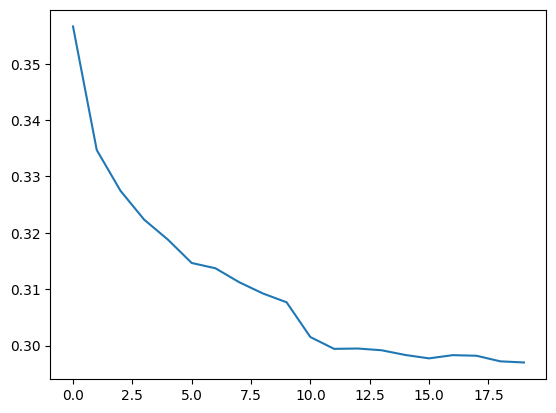

In [45]:
plt.plot(torch.tensor(lossi).view(-1, 10000).mean(1))

In [46]:
# Put layers in eval mode for inference
model.set_training_mode(False)

In [47]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (xtr,ytr),
        'dev': (xdev,ydev),
        'test': (xte,yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('dev')

train 1.9379267692565918
dev 2.030710458755493


In [48]:
# sample from the model
for _ in range(20):
  out = []
  context = [0] * block_size
  while True:
    logits = model(torch.tensor([context]))
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos[i] for i in out))

rilalynn.
al.
jorreani.
mou.
taytha.
s.
milaifa.
branden.
ipary.
janurie.
eliyah.
amih.
mahad.
zayliah.
kings.
draxzri.
khylieye.
avelan.
eliannah.
garyn.
